In [2]:
import torch
import sys
import time

sys.path.append("/home/atuin/v120bb/v120bb18/UnReflectAnything")
from utilities.visualization import rgb, panelize
from polar_highlighter import PolarHighlighter

if torch.cuda.is_available():
    num_devices = torch.cuda.device_count()
    curr_device = torch.cuda.current_device()
    device_name = torch.cuda.get_device_name(curr_device)
    print(f"CUDA is available: {num_devices} device(s) detected.")
    print(f"Current device id: {curr_device} - {device_name}")
else:
    print("CUDA is not available")
%load_ext autoreload
%autoreload 2


CUDA is not available


In [8]:
pwd

'/home/atuin/v120bb/v120bb18/UnReflectAnything/sandboxes'

In [6]:
from main import load_and_process_config
from models_utils import load_best_model_by_run
from dataset import from_config
from utilities import tensor_dict_summarize


config = load_and_process_config("../config_test.yaml")
config.RUN = "clean-dawn-208"
# highlighter = PolarHighlighter(width=448, height=448).cuda()
# dataset = from_config(config)["training"]
model = load_best_model_by_run(config.RUN).eval()

INFO     [10:55:01] Found valid run to resume: /anvme/workspace/v120bb18-unreflectanything/results/clean-dawn-208

INFO     [10:55:01] Latest checkpoint: 
/anvme/workspace/v120bb18-unreflectanything/results/clean-dawn-208/models/weights_best.pt

INFO     [10:55:01] Latest epoch: 13

MODEL    [10:55:05] Model with class UnReflect_Model created with 407,667,011 parameters

In [9]:
torch.save(model.decoders.diffuse.state_dict(), "/home/atuin/v120bb/v120bb18/UnReflectAnything/weights/rgb_decoder.pth")

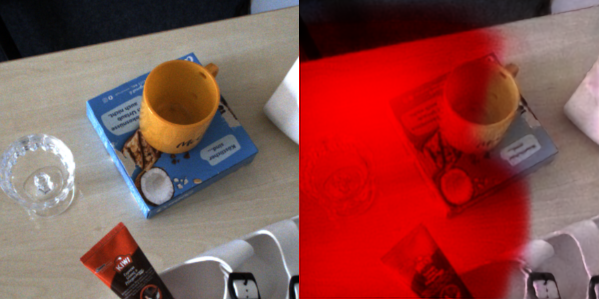

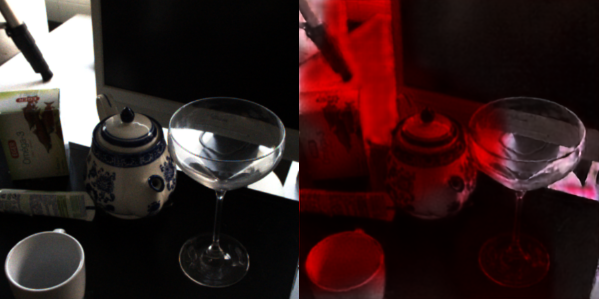

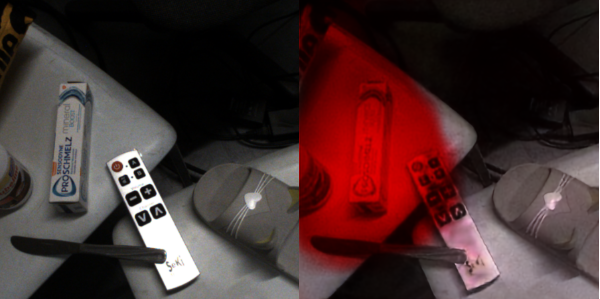

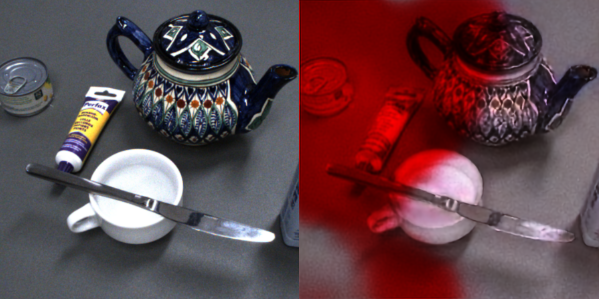

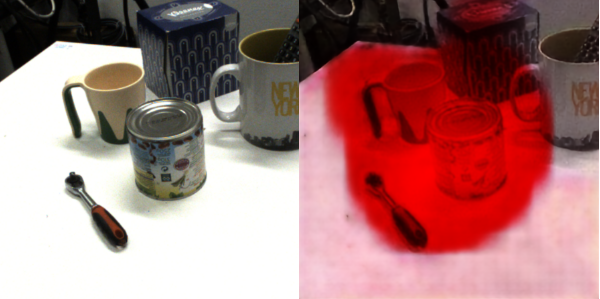

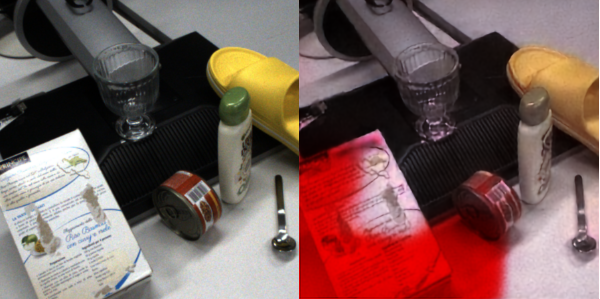

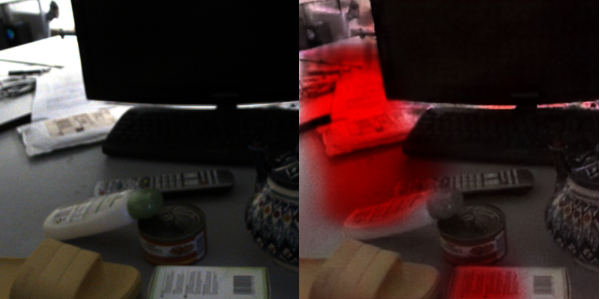

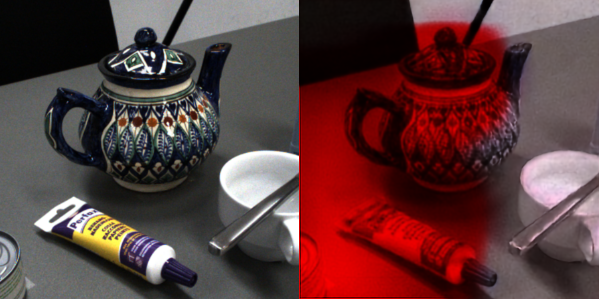

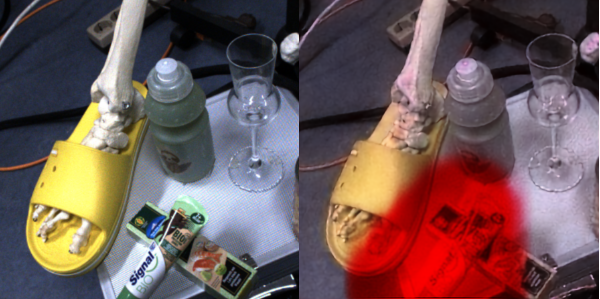

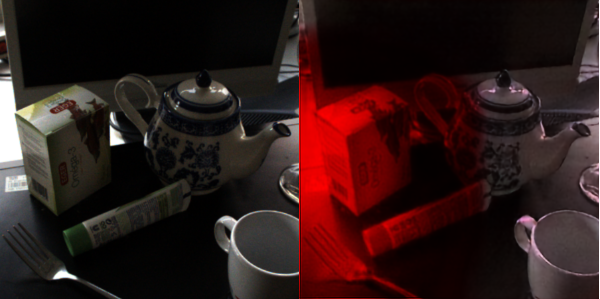

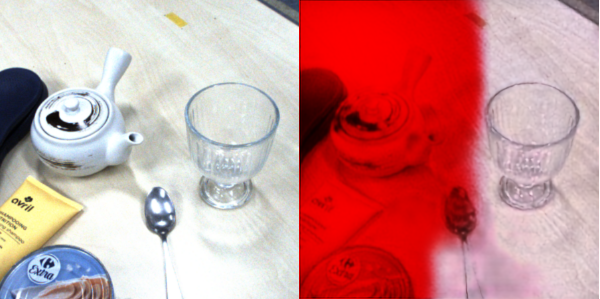

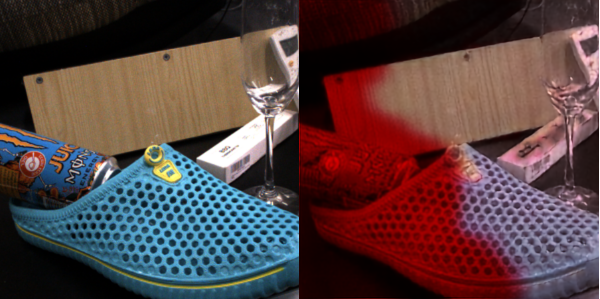

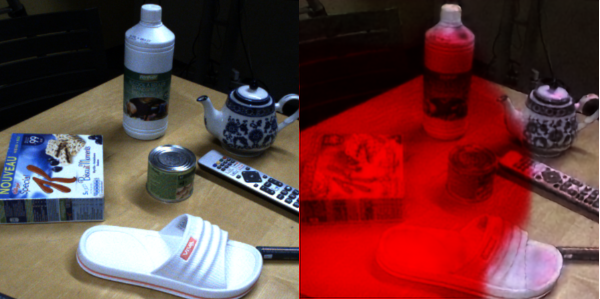

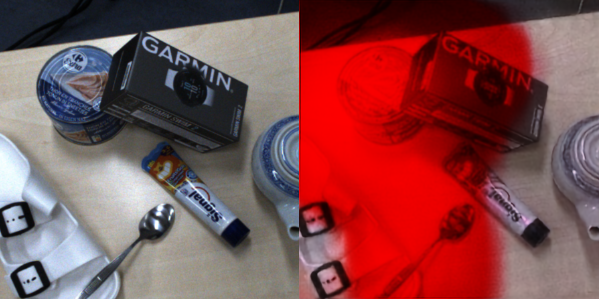

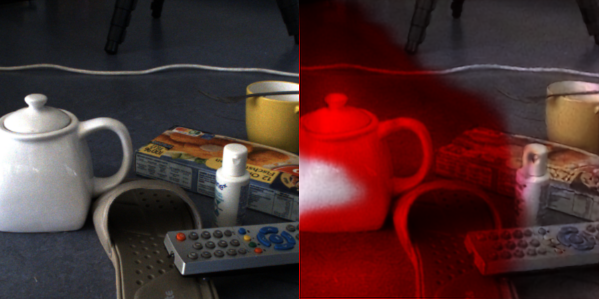

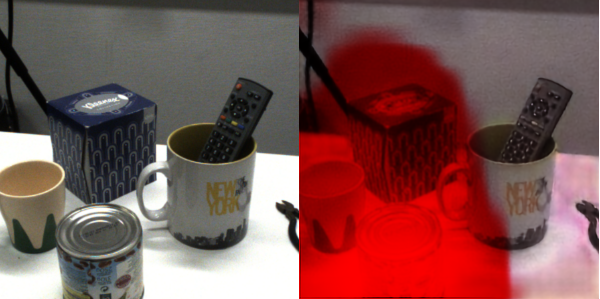

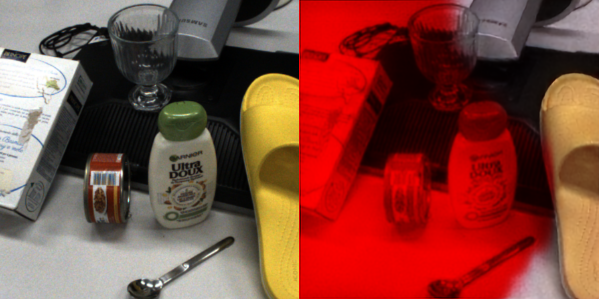

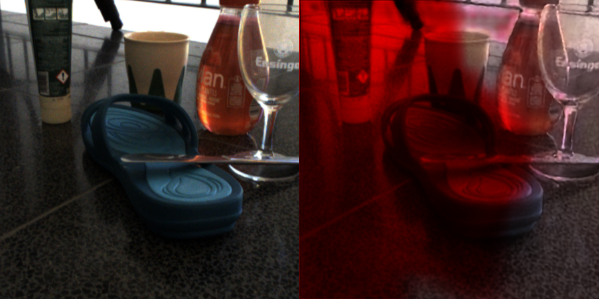

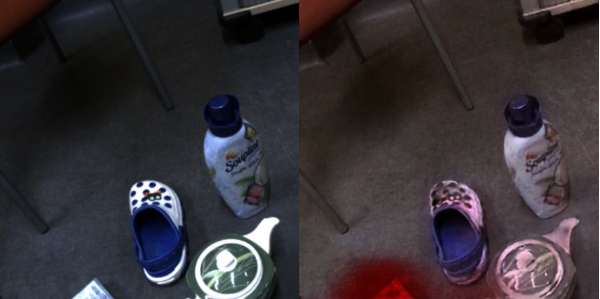

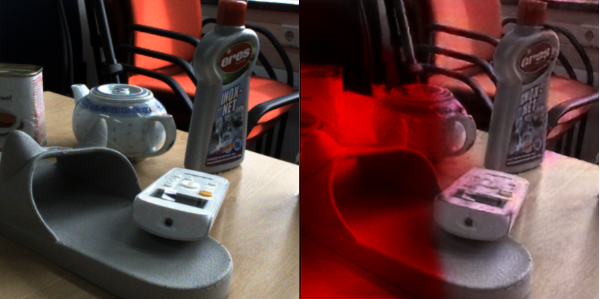

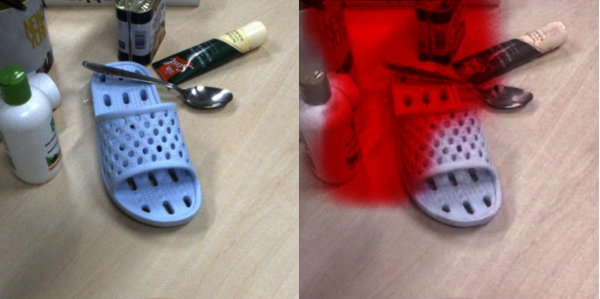

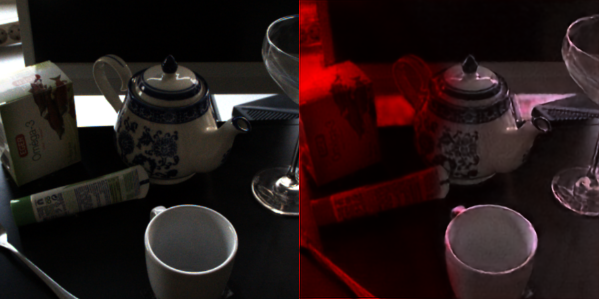

In [19]:
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)

for b, batch in enumerate(dataloader):
    batch = {
        k: v.cuda() if isinstance(v, torch.Tensor) and torch.cuda.is_available() else v
        for k, v in batch.items()
    }
    model_input = {"rgb": batch["raw"]}
    with torch.no_grad():
        modelout = model(model_input)
    rgb(
        panelize(
            rgb(batch["raw"], as_tensor=True, resize=(300, 300)),
            rgb(modelout["diffuse"][0], as_tensor=True, resize=(300, 300)),
        )
    )
    if b > 20:
        break
